## Initialization

In [ ]:
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from astroquery.jplhorizons import Horizons
from lamberthub import gooding1990
from astropy.time import Time
import matplotlib.dates as mdates

AU_KM = 149_597_870.7
DAY_S = 86_400.0

MU_SUN = 2.959122082855911e-4 # AU^3 / day^2
MU_EARTH = 398600.4418  # km^3/s^2
R_EARTH = 6378.1363    # km
R_SOI_EARTH = 924000.0 # km 지구중력권

@dataclass(frozen=True)
class StateVector:
    r: np.ndarray  # position [AU], shape=(3,)
    v: np.ndarray  # velocity [AU/day], shape=(3,)


@dataclass(frozen=True)
class TransferResult:
    # heliocentric spacecraft velocity (au/day)
    v_dep: np.ndarray
    v_arr: np.ndarray

    # planet centered overflow velocity (km/s)
    vinf_dep_vec: np.ndarray
    vinf_arr_vec: np.ndarray

    # -> norm (km/s)
    vinf_dep: float
    vinf_arr: float

    c3: float  #km^2/s^2          
    tof_days: float    

In [ ]:
def au_per_day_to_km_per_s(value):
    return np.asarray(value) * AU_KM / DAY_S

def state_from_horizons(table, index):
    return StateVector(
        r=np.array(
            [table["x"][index], table["y"][index], table["z"][index]],
            dtype=float,
        ),
        v=np.array(
            [table["vx"][index], table["vy"][index], table["vz"][index]],
            dtype=float,
        ),
    )

def state_from_table(table, index):
    row = table.iloc[index]

    return StateVector(
        r=row[["x", "y", "z"]].to_numpy(dtype=float),
        v=row[["vx", "vy", "vz"]].to_numpy(dtype=float),
    )

def solve_lambert(
    earth_dep: StateVector,
    target_arr: StateVector,
    dep_jd: float,
    arr_jd: float,
    *,
    mu: float = MU_SUN,
) -> TransferResult:
    tof_days = float(arr_jd - dep_jd)

    v_sc_departure, v_sc_arrival = gooding1990(
        mu,
        earth_dep.r,
        target_arr.r,
        tof_days,
        M=0,
        prograde=True,
        low_path=True,
    )

     # 태양 중심 우주선 속도 - 태양 중심 행성 속도
    # = 행성 기준 초과속도 벡터 [AU/day]
    vinf_dep_vec_au_day = v_sc_departure - earth_dep.v
    vinf_arr_vec_au_day = v_sc_arrival - target_arr.v

    # 벡터 전체를 km/s로 변환
    vinf_dep_vec_km_s = np.asarray(
        au_per_day_to_km_per_s(vinf_dep_vec_au_day),
        dtype=float,
    )
    vinf_arr_vec_km_s = np.asarray(
        au_per_day_to_km_per_s(vinf_arr_vec_au_day),
        dtype=float,
    )

    vinf_dep_km_s = float(np.linalg.norm(vinf_dep_vec_km_s))
    vinf_arr_km_s = float(np.linalg.norm(vinf_arr_vec_km_s))

    return TransferResult(
        v_dep=v_sc_departure,
        v_arr=v_sc_arrival,
        vinf_dep_vec=vinf_dep_vec_km_s,
        vinf_arr_vec=vinf_arr_vec_km_s,
        vinf_dep=vinf_dep_km_s,
        vinf_arr=vinf_arr_km_s,
        c3=vinf_dep_km_s**2,
        tof_days=tof_days,
    )

def get_pareto_front(df):
    df = df.sort_values("c3_km2_s2")

    best_vinf_arr = np.inf
    pareto_indices = []

    for index, row in df.iterrows():
        if row["vinf_arr_km_s"] < best_vinf_arr:
            pareto_indices.append(index)
            best_vinf_arr = row["vinf_arr_km_s"]

    return df.loc[pareto_indices]

def propagate_sun_2body(r0, v0, dt_days, mu=MU_SUN):
    y0 = np.hstack((r0, v0))

    def rhs(_, y):
        r = y[:3]
        v = y[3:]
        a = -mu * r / np.linalg.norm(r)**3
        return np.hstack((v, a))

    solution = solve_ivp(
        rhs,
        (0.0, dt_days),
        y0,
        rtol=1e-12,
        atol=1e-14,
    )

    return solution.y[:3, -1], solution.y[3:, -1]

def get_rotation_coords(vec_particle, vec_secondary):
    theta = np.arctan2(vec_secondary['y'], vec_secondary['x'])
    omega = (vec_secondary['x'] * vec_secondary['vy'] - vec_secondary['y'] * vec_secondary['vx']) \
            / (vec_secondary['x']**2 + vec_secondary['y']**2)

    dx = vec_particle['x'] - vec_secondary['x']
    dy = vec_particle['y'] - vec_secondary['y']
    dz = vec_particle['z'] - vec_secondary['z']
    
    dvx = vec_particle['vx'] - vec_secondary['vx']
    dvy = vec_particle['vy'] - vec_secondary['vy']
    dvz = vec_particle['vz'] - vec_secondary['vz']
    
    x_rot = dx * np.cos(theta) + dy * np.sin(theta)
    y_rot = -dx * np.sin(theta) + dy * np.cos(theta)
    z_rot = dz
    
    vx_rot = (dvx * np.cos(theta) + dvy * np.sin(theta)) + (omega * y_rot)
    vy_rot = (-dvx * np.sin(theta) + dvy * np.cos(theta)) - (omega * x_rot)
    vz_rot = dvz
    
    return pd.DataFrame({
        'x': x_rot, 'y': y_rot, 'z': z_rot,
        'vx': vx_rot, 'vy': vy_rot, 'vz': vz_rot
    })

## 2100s (Horizons Data)

In [31]:
epochs = {
    "start": "2026-02-01",
    "stop": "2028-02-01",
    "step": "1d",
}

earth = Horizons(
    id="399",             # Earth center
    location="@sun",
    epochs=epochs,
)
earth_vec = earth.vectors(refplane="ecliptic")

mars = Horizons(
    id="499",
    location="@sun",
    epochs=epochs,
)
mars_vec = mars.vectors(refplane="ecliptic")

In [32]:
DEP_START_INDEX = 0
DEP_STOP_INDEX = 9 * 365

TOF_MIN_DAYS = 30
TOF_MAX_DAYS = 730

DATE_STEP_DAYS = 5
TOF_STEP_DAYS = 5

results = []

for dep_index in range(
    DEP_START_INDEX,
    DEP_STOP_INDEX + 1,
    DATE_STEP_DAYS,
):
    for tof_days in range(
        TOF_MIN_DAYS,
        TOF_MAX_DAYS + 1,
        TOF_STEP_DAYS,
    ):
        arr_index = dep_index + tof_days

        if arr_index >= len(mars_vec):
            continue
        
        earth_state = state_from_horizons(earth_vec, dep_index)
        mars_state = state_from_horizons(mars_vec, arr_index)

        try:
            transfer = solve_lambert(
                earth_state,
                mars_state,
                earth_vec["datetime_jd"][dep_index],
                mars_vec["datetime_jd"][arr_index],
            )
        except ValueError:
            continue
        
        results.append({
            "dep_index": dep_index,
            "arr_index": arr_index,

            "dep_jd": earth_vec["datetime_jd"][dep_index],
            "arr_jd": mars_vec["datetime_jd"][arr_index],
            "tof_days": transfer.tof_days,

            "c3_km2_s2": transfer.c3,
            "vinf_dep_km_s": transfer.vinf_dep,
            "vinf_arr_km_s": transfer.vinf_arr,

            "vinf_dep_x_km_s": transfer.vinf_dep_vec[0],
            "vinf_dep_y_km_s": transfer.vinf_dep_vec[1],
            "vinf_dep_z_km_s": transfer.vinf_dep_vec[2],

            "vinf_arr_x_km_s": transfer.vinf_arr_vec[0],
            "vinf_arr_y_km_s": transfer.vinf_arr_vec[1],
            "vinf_arr_z_km_s": transfer.vinf_arr_vec[2],

            "revolutions": 0,
        })

result_df = pd.DataFrame(results)
pareto_df = get_pareto_front(result_df)
low_c3 = result_df.query("c3_km2_s2 <= 50")

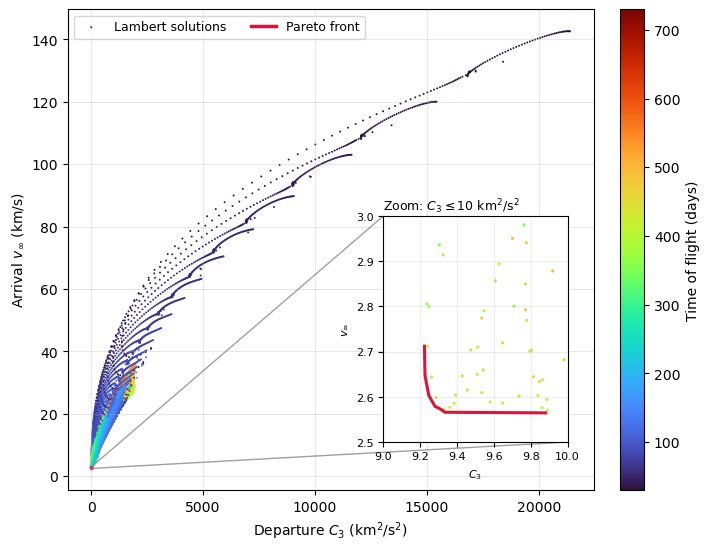

In [35]:
fig, ax1 = plt.subplots(figsize=(7, 5.4), constrained_layout=True)

# 전체 탐색 공간
sc = ax1.scatter(
    result_df["c3_km2_s2"],
    result_df["vinf_arr_km_s"],
    c=result_df["tof_days"],
    cmap="turbo",
    s=2,
    edgecolors="none",
    rasterized=True,
    label="Lambert solutions",
    zorder=1,
)

ax1.plot(
    pareto_df["c3_km2_s2"],
    pareto_df["vinf_arr_km_s"],
    color="crimson",
    linewidth=2.5,
    label="Pareto front",
    zorder=3,
)

ax1.set_xlabel(r"Departure $C_3$ (km$^2$/s$^2$)")
ax1.set_ylabel(r"Arrival $v_\infty$ (km/s)")
ax1.legend(ncol=2, fontsize=9, loc="upper left")
ax1.grid(alpha=0.3)

# 확대창: [왼쪽, 아래, 너비, 높이] — 모두 ax1 내부 비율
ax2 = ax1.inset_axes([0.6, 0.10, 0.35, 0.47])
ax2.set_facecolor("white")

ax2.scatter(
    low_c3["c3_km2_s2"],
    low_c3["vinf_arr_km_s"],
    c=low_c3["tof_days"],
    cmap="turbo",
    s=5,
    edgecolors="none",
    rasterized=True,
    zorder=1,
)

pareto_low = pareto_df[
    pareto_df["c3_km2_s2"] <= 10
]

ax2.plot(
    pareto_low["c3_km2_s2"],
    pareto_low["vinf_arr_km_s"],
    color="crimson",
    linewidth=2.2,
    zorder=3,
)

ax2.set_xlim(9, 10)
ax2.set_ylim(2.5, 3)
ax2.set_title(
    r"Zoom: $C_3 \leq 10$ km$^2$/s$^2$",
    loc="left",
    fontsize=9,
    pad=4,
)

ax2.set_xlabel(r"$C_3$", fontsize=8)
ax2.set_ylabel(r"$v_\infty$", fontsize=8)
ax2.tick_params(labelsize=8)
ax2.grid(alpha=0.22)

# 확대 대상 영역 사각형과 연결선
ax1.indicate_inset_zoom(
    ax2,
    edgecolor="gray",
    alpha=0.75,
    linewidth=1,
)

fig.colorbar(sc, ax=ax1, label="Time of flight (days)")

plt.show()

### Select

In [40]:
c3_target = 9.1

selected = pareto_df.loc[
    (pareto_df["c3_km2_s2"] - c3_target).abs().idxmin()
]

vinf_dep_vec = selected[
    [
        "vinf_dep_x_km_s",
        "vinf_dep_y_km_s",
        "vinf_dep_z_km_s",
    ]
].to_numpy(dtype=float)

print(f"C3 Target    : {c3_target}")
print("---------------------------")
print(f"Departure JD : {selected['dep_jd']:.5f}")
print(f"Arrival JD   : {selected['arr_jd']:.5f}")
print(f"TOF          : {selected['tof_days']:.1f} days")
print(f"C3           : {selected['c3_km2_s2']:.6f} km²/s²")
print(f"Departure v∞ : {selected['vinf_dep_km_s']:.6f} km/s")
print(f"v∞ vector    : {vinf_dep_vec} km/s")

C3 Target    : 9.1
---------------------------
Departure JD : 2461342.50000
Arrival JD   : 2461637.50000
TOF          : 295.0 days
C3           : 9.223252 km²/s²
Departure v∞ : 3.036981 km/s
v∞ vector    : [-1.88117012  2.37107411  0.24991811] km/s


### Escape parabola construct

In [47]:
def unit(vector):
    norm = np.linalg.norm(vector)

    return vector / norm


def rodrigues(vector, axis, angle_rad):
    axis = unit(axis)

    return (
        vector * np.cos(angle_rad)
        + np.cross(axis, vector) * np.sin(angle_rad)
        + axis * np.dot(axis, vector) * (1 - np.cos(angle_rad))
    )


def make_escape_hyperbola(
    vinf_dep_vec,
    parking_alt_km,
    h_hat=None,
):
    # vinf_dep_vec : ndarray, shape (3,) / Lambert 해에서 얻은 지구 기준 출력 초과속도 벡터 [km/s]
    # parking_alt_km : float / 주차궤도 고도 [km]
    # h_hat : ndarray, shape (3,), optional / 탈출 쌍곡선 궤도면의 법선 단위벡터 (none이면 임의)
    
    vinf = np.linalg.norm(vinf_dep_vec)
    s_hat = unit(vinf_dep_vec)

    # 궤도 평면
    if h_hat is None:
        reference = np.array([0.0, 0.0, 1.0])

        # vinf가 z축과 거의 평행하면 다른 기준축 사용
        if abs(np.dot(s_hat, reference)) > 0.99:
            reference = np.array([0.0, 1.0, 0.0])

        h_hat = unit(np.cross(s_hat, reference))
    else:
        h_hat = unit(h_hat)

    # 궤도면 불일치
    if not np.isclose(np.dot(s_hat, h_hat), 0.0, atol=1e-8):
        raise ValueError(
            "h_hat must be perpendicular to vinf_dep_vec "
            "for a coplanar parking-orbit injection."
        )

    r_p = R_EARTH + parking_alt_km

    # 쌍곡선 궤도 요소
    e = 1 + r_p * vinf**2 / MU_EARTH
    f = np.arccos(-1 / e) # 진근점이각

    # 근지점 벡터 계산
    r_hat_p = rodrigues(s_hat, h_hat, -f) # 속도벡터 회전 -> 근지점 설정
    t_hat_p = unit(np.cross(h_hat, r_hat_p)) # 위치벡터 구하기
    v_hyp_p = np.sqrt(vinf**2 + 2 * MU_EARTH / r_p) # 속도 구하기
    v_circ = np.sqrt(MU_EARTH / r_p) # 케플러 속도

    r_p_vec = r_p * r_hat_p # 근지점 위치벡터
    v_hyp_p_vec = v_hyp_p * t_hat_p # 쌍곡선궤도 속도벡터
    v_parking_vec = v_circ * t_hat_p # 주차궤도 속도벡터
    delta_v_tmi_vec = v_hyp_p_vec - v_parking_vec # injection 시 Delta V

    return {
        "r_p_km": r_p_vec,
        "v_hyp_p_km_s": v_hyp_p_vec,
        "v_parking_km_s": v_parking_vec,
        "delta_v_tmi_km_s": delta_v_tmi_vec,

        "r_p_norm_km": np.linalg.norm(r_p_vec),
        "v_hyp_p_norm_km_s": np.linalg.norm(v_hyp_p_vec),
        "delta_v_tmi_norm_km_s": np.linalg.norm(delta_v_tmi_vec),

        "vinf_norm_km_s": vinf,
        "eccentricity": e,
        "f_inf_deg": np.degrees(f),
        "h_hat": h_hat,
    }

escape = make_escape_hyperbola(
    vinf_dep_vec,
    parking_alt_km=200.0,
)

print(f"Earth departure v∞: {escape['vinf_norm_km_s']:.4f} km/s")
print(f"Hyperbola eccentricity: {escape['eccentricity']:.6f}")
print(f"Asymptote true anomaly: {escape['f_inf_deg']:.3f} deg")
print(f"Δv: {escape['delta_v_tmi_norm_km_s']:.4f} km/s")

print("\nGeocentric r at burn point [km]")
print(escape["r_p_km"])

print("\nGeocentric v after burn [km/s]")
print(escape["v_hyp_p_km_s"])

Earth departure v∞: 3.0370 km/s
Hyperbola eccentricity: 1.152212
Asymptote true anomaly: 150.215 deg
Δv: 3.6356 km/s

Geocentric r at burn point [km]
[ 3369.22976381 -4246.6618889  -3726.39648741]

Geocentric v after burn [km/s]
[-4.02075591  5.06786182 -9.41079305]


### Earth SOI

In [54]:
def propagate_to_soi(
    r0_km,
    v0_km_s,
    r_soi_km=R_SOI_EARTH,
):
    y0 = np.hstack((r0_km, v0_km_s))

    def rhs(_, y):
        r = y[:3]
        v = y[3:]

        a = -MU_EARTH * r / np.linalg.norm(r)**3

        return np.hstack((v, a))

    def soi_crossing(_, y):
        r = y[:3]

        return np.linalg.norm(r) - r_soi_km

    soi_crossing.terminal = True
    soi_crossing.direction = 1  # 지구에서 멀어지는 방향만 감지

    solution = solve_ivp(
        rhs,
        (0.0, 10 * 86400.0),  # 최대 10일, 보통 SOI 전에 종료
        y0,
        method="DOP853",
        rtol=1e-12,
        atol=1e-10,
        events=soi_crossing,
    )

    if not solution.t_events[0].size:
        raise RuntimeError("Earth SOI was not reached.")

    return {
        "tof_s": solution.t[-1],
        "tof_days": solution.t[-1] / 86400.0,
        "r_soi_km": solution.y[:3, -1],
        "v_soi_km_s": solution.y[3:, -1],
        "solution": solution,
    }

earth_escape = propagate_to_soi(
    escape["r_p_km"],
    escape["v_hyp_p_km_s"],
)

earth_escape_jd = selected['dep_jd'] + earth_escape['tof_days']

print(f"Time to SOI: {earth_escape['tof_days']} days")
print(f"Time at SOI: JD {earth_escape_jd}")
print("\nGeocentric r at SOI [km]")
print(earth_escape["r_soi_km"])
print("\nGeocentric v at SOI [km/s]")
print(earth_escape["v_soi_km_s"])

Time to SOI: 3.0785782480092205 days
Time at SOI: JD 2461345.578578248

Geocentric r at SOI [km]
[-573385.9403105   722710.05275586   51910.91503588]

Geocentric v at SOI [km/s]
[-1.96728134  2.47961085  0.25953449]


In [ ]:
earth_soi_horizons = Horizons(
    id="399",
    location="@sun",
    epochs=earth_escape_jd,
)
earth_soi_state_vec = earth_soi_horizons.vectors(refplane="ecliptic")

earth_soi_state = state_from_horizons(earth_soi_state_vec, 0)

r_soi_au = (
    earth_soi_state.r
    + earth_escape["r_soi_km"] / AU_KM
)

v_soi_au_day = (
    earth_soi_state.v
    + earth_escape["v_soi_km_s"] * DAY_S / AU_KM
)

# Mercury6에 사용할 값
print("\nHeliocentric r at SOI [au]")
print(r_soi_au)
print("\nHeliocentric v at SOI [au/day]")
print(v_soi_au_day)


Heliocentric r at SOI [au]
[7.75366418e-01 6.19836043e-01 3.03216889e-04]

Heliocentric v at SOI [au/day]
[-0.01206837  0.01487494  0.00014968]


### Error correction

In [ ]:
ARR_JD = selected['arr_jd']
DV_TEST = 1e-6  # AU/day

for axis, i in zip(["vx", "vy", "vz"], range(3)):
    v_test = v_soi_au_day.copy() #이거 넣으면 안됨 고치기
    v_test[i] += DV_TEST

    print(f"\n=== {axis} + {DV_TEST:.1e} AU/day ===")
    print("r [AU]    :", r_soi_au)
    print("v [AU/day]:", v_test)


=== vx + 1.0e-06 AU/day ===
r [AU]    : [ 0.4835385  -0.89729962 -0.03789595]
v [AU/day]: [ 0.0148373   0.0078598  -0.00248766]

=== vy + 1.0e-06 AU/day ===
r [AU]    : [ 0.4835385  -0.89729962 -0.03789595]
v [AU/day]: [ 0.0148363   0.0078608  -0.00248766]

=== vz + 1.0e-06 AU/day ===
r [AU]    : [ 0.4835385  -0.89729962 -0.03789595]
v [AU/day]: [ 0.0148363   0.0078598  -0.00248666]


In [39]:
ARR_JD = 2487722.5
DV_TEST = 1e-6  # AU/day

col = ['time', 'x', 'y', 'z', 'vx', 'vy', 'vz']

earth_run1_vec = pd.read_csv('EARTH_run1.aei', sep=r'\s+', skiprows=4, names=col)
aa29_run1_vec = pd.read_csv('2002AA29_run1.aei', sep=r'\s+', skiprows=4, names=col)
space_run1_vec = pd.read_csv('SPACECRAFT_run1.aei', sep=r'\s+', skiprows=4, names=col)

x_earth_run1, y_earth_run1, z_earth_run1 = earth_run1_vec['x'], earth_run1_vec['y'], earth_run1_vec['z']
x_aa29_run1, y_aa29_run1, z_aa29_run1 = aa29_run1_vec['x'], aa29_run1_vec['y'], aa29_run1_vec['z']

space_vec_vx = pd.read_csv('SPACECRAFT-vx.aei', sep=r'\s+', skiprows=4, names=col)
space_vec_vy = pd.read_csv('SPACECRAFT-vy.aei', sep=r'\s+', skiprows=4, names=col)
space_vec_vz = pd.read_csv('SPACECRAFT-vz.aei', sep=r'\s+', skiprows=4, names=col)

initial_velocity = np.array([
    0.0148363,
    0.0078598,
   -0.00248766,
])

def au_per_day_to_m_per_s(value):
    return np.asarray(value) * AU_KM * 1000 / DAY_S

def miss_vector(vec_sc, vec_aa29, arr_jd=ARR_JD):
    df = (
        vec_sc.merge(vec_aa29, on="time", suffixes=("_sc", "_aa29"))
        .sort_values("time")
    )

    row = df.loc[(df["time"] - arr_jd).abs().idxmin()]

    return np.array([
        row["x_sc"] - row["x_aa29"],
        row["y_sc"] - row["y_aa29"],
        row["z_sc"] - row["z_aa29"],
    ])

dr0 = miss_vector(space_run1_vec, aa29_run1_vec)
dr0_total = np.linalg.norm(dr0)
drx = miss_vector(space_vec_vx, aa29_run1_vec)
dry = miss_vector(space_vec_vy, aa29_run1_vec)
drz = miss_vector(space_vec_vz, aa29_run1_vec)

J0 = np.column_stack([
    (drx - dr0) / DV_TEST,
    (dry - dr0) / DV_TEST,
    (drz - dr0) / DV_TEST,
])

dv1 = np.linalg.solve(J0, -dr0)
velocity_run2 = initial_velocity + dv1

print("Run 1 miss [km]:", dr0 * AU_KM)
print("Run 1 miss norm [km]:", dr0_total * AU_KM)
print("First correction [m/s]:", au_per_day_to_m_per_s(dv1))
print("Run 2 initial velocity [AU/day]:", velocity_run2)

Run 1 miss [km]: [-80023.67090377 -51595.36313785  67487.93781102]
Run 1 miss norm [km]: 116706.85991930836
First correction [m/s]: [ -8.61649435  -5.10867713 -73.27546606]
Run 2 initial velocity [AU/day]: [ 0.01483132  0.00785685 -0.00252998]


In [35]:
space_run2_vec = pd.read_csv("SPACECRAFT-run2.aei", sep=r"\s+", skiprows=4, names=col,)

dr1 = miss_vector(space_run2_vec, aa29_run1_vec)
dr1_total = np.linalg.norm(dr1)

dv2 = np.linalg.solve(J0, -dr1)
velocity_run3 = velocity_run2 + dv2

print("Run 2 miss [km]:", dr1 * AU_KM)
print("Run 2 miss norm [km]:", dr1_total * AU_KM)
print("Second correction [m/s]:", au_per_day_to_m_per_s(dv2))
print("Run 3 initial velocity [AU/day]:", velocity_run3)


Run 2 miss [km]: [2901.39086308 2969.09885935 -822.44421375]
Run 2 miss norm [km]: 4232.024510993254
Second correction [m/s]: [-0.01901654 -0.0203404   0.39587102]
Run 3 initial velocity [AU/day]: [ 0.01483131  0.00785684 -0.00252975]


In [40]:
space_run3_vec = pd.read_csv("SPACECRAFT-run3.aei", sep=r"\s+", skiprows=4, names=col,)
x_space_run3, y_space_run3, z_space_run3 = space_run3_vec['x'], space_run3_vec['y'], space_run3_vec['z']

dr2 = miss_vector(space_run3_vec, aa29_run1_vec)
dr2_total = np.linalg.norm(dr2)

dv3 = np.linalg.solve(J0, -dr2)
velocity_run4 = velocity_run3 + dv3

print("Run 3 miss [km]:", dr2 * AU_KM)
print("Run 3 miss norm [km]:", dr2_total * AU_KM)

print(
    "Net correction [m/s]:",
    np.linalg.norm(au_per_day_to_m_per_s(velocity_run4 - initial_velocity)),
)

Run 3 miss [km]: [17.66750853 41.27405252  9.21522884]
Run 3 miss norm [km]: 45.83239805578092
Net correction [m/s]: 73.58686289502639


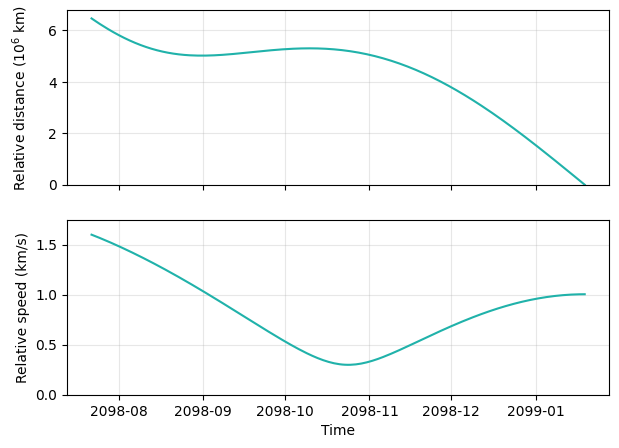

Final distance : 45.8 km
Minimum distance: 45.8 km
Final Δv       : 1.0048 km/s


In [130]:
df = (
    space_run3_vec.merge(aa29_run1_vec, on="time", suffixes=("_sc", "_aa29"))
    .sort_values("time")
)

time_date = Time(
    df["time"].to_numpy(),
    format="jd",
    scale="tdb",
).to_datetime()

dr_au = np.sqrt(
    (df["x_sc"] - df["x_aa29"])**2
    + (df["y_sc"] - df["y_aa29"])**2
    + (df["z_sc"] - df["z_aa29"])**2
)

dr_km = dr_au * AU_KM
dr_million_km = dr_km / 1e6

dv_km_s = np.sqrt(
    (df["vx_sc"] - df["vx_aa29"])**2
    + (df["vy_sc"] - df["vy_aa29"])**2
    + (df["vz_sc"] - df["vz_aa29"])**2
) * AU_KM / DAY_S

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(7, 5),
    sharex=True,
)

ax1.plot(time_date, dr_million_km, color="lightseagreen")
ax1.set_ylabel(r"Relative distance ($10^6$ km)")
ax1.set_ylim(0, 6.8)
ax1.grid(alpha=0.3)

ax2.plot(time_date, dv_km_s, color="lightseagreen")
ax2.set_xlabel("Time")
ax2.set_ylabel(r"Relative speed (km/s)")
ax2.set_ylim(0, 1.75)
ax2.grid(alpha=0.3)

fig.align_ylabels()

fig.savefig(
    "aa29_approach_parameters.webp",
    format="webp",
    dpi=220,
    bbox_inches="tight",
)

plt.show()

print(f"Final distance : {dr_km.iloc[-1]:,.1f} km")
print(f"Minimum distance: {dr_km.min():,.1f} km")
print(f"Final Δv       : {dv_km_s.iloc[-1]:.4f} km/s")

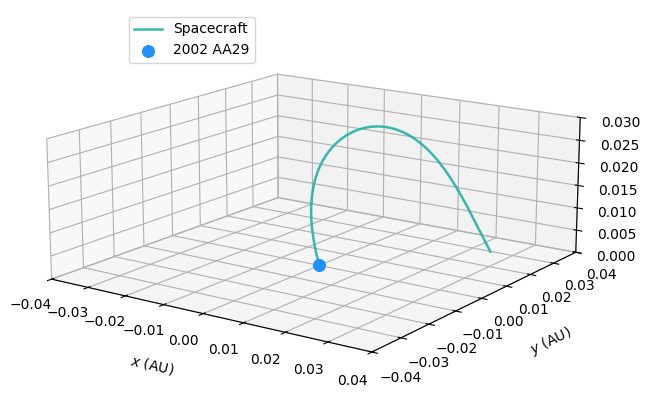

In [133]:
vec_space_rot = get_rotation_coords(space_run3_vec, aa29_run1_vec)
x_rot, y_rot, z_rot = vec_space_rot['x'], vec_space_rot['y'], vec_space_rot['z']

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    x_rot, y_rot, z_rot,
    color="lightseagreen",
    lw=1.8,
    alpha=0.9,
    label="Spacecraft",
)

ax.scatter(
    0, 0, 0,
    color="dodgerblue",
    s=70,
    depthshade=False,
    label="2002 AA29",
    zorder=5,
)

ax.set_xlim(-0.04, 0.04)
ax.set_ylim(-0.04, 0.04)
ax.set_zlim(0, 0.03)

ax.set_xlabel("$x$ (AU)", labelpad=8)
ax.set_ylabel("$y$ (AU)", labelpad=8)
ax.set_zlabel("$z$ (AU)", labelpad=8)

ax.view_init(elev=15, azim=-55)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
ax.set_box_aspect((1, 1, 0.375), zoom=1.4)

fig.savefig(
    "aa29_approach_3d.webp",
    format="webp",
    dpi=220,
    bbox_inches="tight",
)

plt.show()

## 2600s (mercury6)

In [124]:
col = ['time', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'a', 'e', 'i', 'g', 'n', 'M']

earth_2600_vec = pd.read_csv('EARTH.aei', sep=r'\s+', skiprows=4, names=col)
aa29_2600_vec = pd.read_csv('2002AA29.aei', sep=r'\s+', skiprows=4, names=col)

In [125]:
DEP_START_INDEX = 27 * 365
DEP_STOP_INDEX = 37 * 365

TOF_MIN_DAYS = 30
TOF_MAX_DAYS = 730

DATE_STEP_DAYS = 5
TOF_STEP_DAYS = 5

results_2600 = []

for dep_index in range(
    DEP_START_INDEX,
    DEP_STOP_INDEX + 1,
    DATE_STEP_DAYS,
):
    for tof_days in range(
        TOF_MIN_DAYS,
        TOF_MAX_DAYS + 1,
        TOF_STEP_DAYS,
    ):
        arr_index = dep_index + tof_days

        if arr_index >= len(aa29_2600_vec):
            continue

        try:
            result = solve_lambert(
                state_from_table(earth_2600_vec, dep_index),
                state_from_table(aa29_2600_vec, arr_index),
                earth_2600_vec["time"][dep_index],
                aa29_2600_vec["time"][arr_index],
            )
        except ValueError:
            continue

        results_2600.append({
            "dep_jd": earth_2600_vec["time"][dep_index],
            "arr_jd": aa29_2600_vec["time"][arr_index],
            "tof_days": result.tof_days,
            "c3_km2_s2": result.c3,
            "vinf_dep_km_s": result.vinf_dep,
            "vinf_arr_km_s": result.vinf_arr,
            "revolutions": 0,
        })

results_2600_df = pd.DataFrame(results_2600)
pareto_2600_df = get_pareto_front(results_2600_df)
low_c3_2600 = results_2600_df.query("c3_km2_s2 <= 50")

KeyboardInterrupt: 

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), constrained_layout=True)

ax1.scatter(
    results_2600_df["c3_km2_s2"],
    results_2600_df["vinf_arr_km_s"],
    s=2,
    color="lightseagreen",
    alpha=0.15,
    label="Lambert solutions",
)

ax1.plot(
    pareto_2600_df["c3_km2_s2"],
    pareto_2600_df["vinf_arr_km_s"],
    color="darkslategray",
    linewidth=2,
    label="Pareto front",
)

ax1.set_ylabel(r"Arrival $v_\infty$ (km/s)")
ax1.legend(ncol=2, fontsize=9)
ax1.grid(alpha=0.3)

ax2.scatter(
    low_c3_2600["c3_km2_s2"],
    low_c3_2600["vinf_arr_km_s"],
    s=5,
    color="lightseagreen",
    alpha=0.15,
    label=r"Lambert solutions ($C_3 \leq 50$ km$^2$/s$^2$)",
)

ax2.plot(
    pareto_2600_df["c3_km2_s2"],
    pareto_2600_df["vinf_arr_km_s"],
    color="darkslategray",
    linewidth=2,
    label="Pareto front",
)

ax2.set_xlabel(r"$C_3$ (km$^2$/s$^2$)")
ax2.set_ylabel(r"Arrival $v_\infty$ (km/s)")
ax2.legend(ncol=2, fontsize=9)
ax2.grid(alpha=0.3)

fig.savefig(
    "v_c3_2600.webp",
    format="webp",
    dpi=220,
    bbox_inches="tight",
    pad_inches=0.06,
)

plt.show()

In [ ]:
plt.rcdefaults()
fig, (ax0, ax1) = plt.subplots(
    2, 1,
    figsize=(7, 6),
    sharex=True,
    height_ratios=[2.2, 1],
    constrained_layout=True,
)

# 위: 두 Pareto front와 그 차이
ax0.plot(c_grid, v_2100, color="dodgerblue", lw=2, label="2100s")
ax0.plot(c_grid, v_qs, color="lightseagreen", lw=2, label="Quasi-satellite phase")

ax0.fill_between(
    c_grid,
    v_2100,
    v_qs,
    color="gray",
    alpha=0.25,
    label=r"$\Delta v_\infty$",
)

ax0.set_ylabel(r"Arrival $v_\infty$ (km/s)")
ax0.set_xlim(c_grid.min(), c_grid.max())
ax0.legend()
ax0.grid(alpha=0.3)

# 아래: signed difference
ax1.axhline(0, color="black", lw=0.8)

ax1.fill_between(
    c_grid, 0, delta_vinf,
    where=delta_vinf >= 0,
    color="tab:red",
    alpha=0.35,
    label="QS worse",
)

ax1.fill_between(
    c_grid, 0, delta_vinf,
    where=delta_vinf < 0,
    color="tab:green",
    alpha=0.35,
    label="QS better",
)

ax1.plot(c_grid, delta_vinf, color="black", lw=1)

ax1.set_xlabel(r"$C_3$ (km$^2$/s$^2$)")
ax1.set_ylabel(r"$\Delta v_\infty$" "\n(km/s)")
ax1.legend(ncol=2, fontsize=9)
ax1.grid(alpha=0.3)

fig.savefig(
    "pareto_front_comparison.webp",
    format="webp",
    dpi=220,
    bbox_inches="tight",
    pad_inches=0.06,
)

plt.show()